# Clustering de Soluciones de Incidentes y Clasificador para Tickets Nuevos

Este notebook construye un catálogo de **soluciones por defecto** para incidentes bancarios cerrados.

**Enfoque (dos etapas):**
1. **Clustering no supervisado** de `close_notes` (TF-IDF + SVD + KMeans) sobre tickets cerrados, para descubrir *tipos de solución* reales. Cada cluster se perfila con su solución por defecto (la `close_notes` más frecuente del cluster).
2. **Clasificador supervisado** que, usando solo información disponible al crear el ticket (descripción, subcategoría, aplicación, datos del usuario afectado — sin `close_notes`), predice a qué cluster de solución pertenecerá un ticket nuevo, para sugerir directamente su solución por defecto.

Los artefactos entrenados se guardan en `Analisis/modelo_soluciones/` y el catálogo en `output/catalogo_soluciones_default_<fecha>.csv`.

In [ ]:
import os
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (10, 6)})

nltk.download('stopwords', quiet=True)


## 1. Carga de Datos

Cargamos el export de incidentes (`incidentes_2026-05-28_17-09-42.csv`, separador `;`). A diferencia de otros notebooks de este proyecto, este archivo **no incluye** una columna de categorización curada (`Categoría`/`Clasificación`).

In [ ]:
ruta_csv = os.path.join(os.path.dirname(os.getcwd()), 'Data', 'incidentes_2026-05-28_17-09-42.csv')
print('Directorio actual:', os.getcwd())
print('Ruta CSV:', ruta_csv)

df = pd.read_csv(ruta_csv, sep=';', encoding='latin-1')

print('Dimensiones:', df.shape)
df.head()
df.info()
df.isnull().sum().sort_values(ascending=False).head(15)

Directorio actual: c:\Users\paomaribel\Documents\GitHub\Asignador\Analisis
Ruta CSV: c:\Users\paomaribel\Documents\GitHub\Asignador\Data\incidentes_2026-05-28_17-09-42.csv
Dimensiones: (23147, 28)
<class 'pandas.DataFrame'>
RangeIndex: 23147 entries, 0 to 23146
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   number                      23147 non-null  str    
 1   state                       23147 non-null  str    
 2   sys_created_on              23147 non-null  str    
 3   category                    23147 non-null  str    
 4   u_subcategory               23147 non-null  str    
 5   u_subcategory_2             23147 non-null  str    
 6   contact_type                23147 non-null  str    
 7   business_duration           23082 non-null  float64
 8   cmdb_ci_business_app        11146 non-null  str    
 9   short_description           23147 non-null  str    
 10  priority        

cmdb_ci_business_app          12001
location.cmn_location_type     8097
location                       8097
comments_and_work_notes        7805
u_subcategoria_error           3612
u_categoria_error              3610
resolved_at                    2637
close_notes                    2606
u_affected_user.department     1236
u_affected_user.title          1011
u_affected_user.company        1011
u_affected_user                1011
description                     299
business_duration                65
caller_id                        63
dtype: int64

## 2. Filtrado de Tickets Cerrados

Solo los tickets en estado `Cerrado` o `Resuelto` tienen `close_notes` (la solución aplicada) poblado. A partir de aquí, todo el análisis trabaja sobre `df_cerrados`.

In [37]:
df_cerrados = df[df['state'].isin(['Cerrado', 'Resuelto'])].copy()

print(f"Tickets totales: {len(df)}")
print(f"Tickets cerrados/resueltos: {len(df_cerrados)} "
      f"({len(df_cerrados) / len(df) * 100:.1f}%)")
print()
print("Distribución de 'state':")
print(df['state'].value_counts(dropna=False))
print()
print('Nulos en close_notes (solo cerrados/resueltos):', df_cerrados['close_notes'].isnull().sum())

Tickets totales: 23147
Tickets cerrados/resueltos: 20510 (88.6%)

Distribución de 'state':
state
Cerrado       20439
Cancelado      2571
Resuelto         71
Nuevo            25
En proceso       25
Pendiente        16
Name: count, dtype: int64

Nulos en close_notes (solo cerrados/resueltos): 0


## 3. Columnas Candidatas para Establecer la Solución

Para construir un catálogo de soluciones necesitamos: (a) el texto de la solución en sí, y (b) entender si alguna columna existente podría servir como agrupador (taxonomía) de soluciones. Revisemos nulos y cardinalidad de las columnas candidatas.

In [38]:
columnas_candidatas = [
    'close_notes', 'category', 'u_categoria_error', 'u_subcategoria_error',
    'cmdb_ci_business_app', 'assignment_group', 'u_subcategory', 'u_subcategory_2',
    'short_description', 'description',
]
resumen_cols = pd.DataFrame({
    'pct_nulos': df_cerrados[columnas_candidatas].isnull().mean() * 100,
    'valores_unicos': df_cerrados[columnas_candidatas].nunique(),
}).sort_values('pct_nulos')
resumen_cols

,pct_nulos,valores_unicos
close_notes,0.000000,15300
category,0.000000,8
u_subcategory,0.000000,16
assignment_group,0.000000,3
u_subcategory_2,0.000000,32
short_description,0.000000,15759
description,1.452950,15510
u_categoria_error,4.846416,10
u_subcategoria_error,4.856168,53
cmdb_ci_business_app,52.852267,27


In [39]:
df_cerrados['category'].value_counts(dropna=False)

category
Aplicaciones                  10153
Operación TI                   9532
Operacion TI                    741
Pedidos de Información           51
Atención Puesto de Trabajo       20
Infraestructura                   6
admon_entorno                     5
Usuarios y Accesos                2
Name: count, dtype: int64

**Conclusiones de esta sección:**
- `close_notes` es el texto que describe la **solución aplicada** y está presente en el 100% de los tickets cerrados/resueltos: es la base del catálogo de soluciones.
- `category` solo tiene 8 valores muy generales (`Aplicaciones`, `Operación TI`, `Operacion TI`, `Pedidos de Información`, ...) y además `"Operación TI"` y `"Operacion TI"` corresponden al mismo grupo escrito con distinta codificación — ni siquiera esta columna está limpia.
- `u_categoria_error`/`u_subcategoria_error` describen el **tipo de error técnico** (no necesariamente el tipo de solución aplicada) y tienen ~5% de nulos.
- Ninguna columna existente constituye una taxonomía curada de *soluciones*. Por eso, en lugar de agrupar por una columna existente, **descubrimos los tipos de solución directamente desde el texto de `close_notes`** mediante clustering no supervisado.

## 4. Exploración de close_notes

count    20510.000000
mean       171.649342
std        370.335363
min          1.000000
25%         57.000000
50%        100.000000
75%        187.000000
max      24148.000000
Name: close_notes_len, dtype: float64


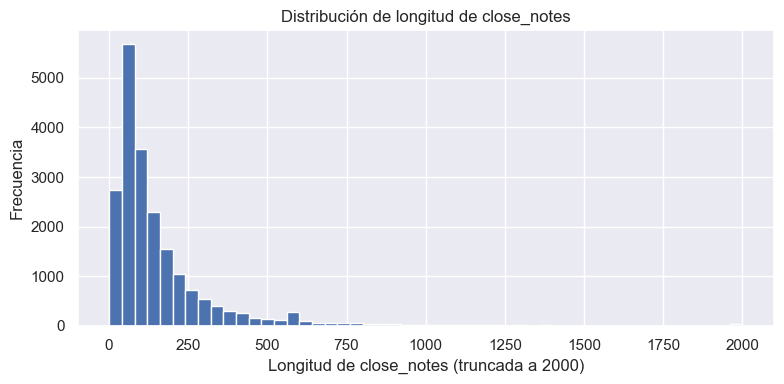

In [40]:
df_cerrados['close_notes_len'] = df_cerrados['close_notes'].fillna('').str.len()
print(df_cerrados['close_notes_len'].describe())

plt.figure(figsize=(8, 4))
df_cerrados['close_notes_len'].clip(upper=2000).hist(bins=50)
plt.xlabel('Longitud de close_notes (truncada a 2000)')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitud de close_notes')
plt.tight_layout()
plt.show()

In [41]:
def normalizar_close_notes(texto):
    if pd.isnull(texto):
        return ""
    texto = str(texto).strip().lower()
    texto = re.sub(r'\s+', ' ', texto)
    return texto

df_cerrados['close_notes_norm'] = df_cerrados['close_notes'].apply(normalizar_close_notes)

df_cerrados[['close_notes', 'close_notes_norm']].head(3)

,close_notes,close_notes_norm
8,Por favor su ayuda realizando las siguientes a...,por favor su ayuda realizando las siguientes a...
12,Por favor re ejecutar a proceso cancelado en t...,por favor re ejecutar a proceso cancelado en t...
15,Se ha cerrado la tarea asociada a la alerta: A...,se ha cerrado la tarea asociada a la alerta: a...


In [42]:
total = len(df_cerrados)
unicos = df_cerrados['close_notes_norm'].nunique()
print(f'Total de tickets cerrados: {total}')
print(f'close_notes_norm únicos: {unicos}')
print(f'Ratio de repetición global: {1 - unicos / total:.3f}')
print()
print('Soluciones (close_notes_norm) más frecuentes:')
top10 = df_cerrados['close_notes_norm'].value_counts().head(10)
for sol, freq in top10.items():
    print(f'{freq:5d} ({freq/total*100:4.1f}%) | {sol[:100]}')

Total de tickets cerrados: 20510
close_notes_norm únicos: 14672
Ratio de repetición global: 0.285

Soluciones (close_notes_norm) más frecuentes:
  289 ( 1.4%) | requerimiento atendido
  176 ( 0.9%) | se procede con dar por bueno el proceso en test
  165 ( 0.8%) | se adjunta documento solicitado
  154 ( 0.8%) | se procede con dar por bueno el proceso
  153 ( 0.7%) | revisión de logs validación del proceso
  122 ( 0.6%) | requerimiento atendido, se procede con el cierre del ticket
   86 ( 0.4%) | requerimiento atendido se procede con el cierre del ticket.
   81 ( 0.4%) | se adjunta comprobante solicitado
   77 ( 0.4%) | por favor dar por bueno a proceso cancelado en test
   63 ( 0.3%) | alerta recuperada


## 5. Limpieza de Texto para Clustering

Para el clustering necesitamos un texto más limpio que `close_notes_norm`. A diferencia de simplemente eliminar números/códigos, aquí los **enmascaramos** con placeholders semánticos (`url`, `email`, `fecha`, `num_largo`, `num`): esto preserva la señal de que una solución hace referencia a un proceso, una cuenta o una fecha programada (útil para distinguir tipos de solución como "ejecución de proceso batch" de "se brindó información"), sin inundar el vocabulario TF-IDF con miles de códigos/cuentas distintos.

In [ ]:
def normalize_text_close_notes(texto):
    if pd.isnull(texto):
        return ""
    t = str(texto).strip().lower()
    t = unicodedata.normalize('NFKD', t).encode('ascii', 'ignore').decode('utf-8', errors='ignore')

    t = re.sub(r'(https?://\S+|www\.\S+)', ' url ', t)
    t = re.sub(r'\b[\w.-]+@[\w.-]+\.\w+\b', ' email ', t)
    t = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', ' fecha ', t)
    t = re.sub(r'\b\d{7,}\b', ' num_largo ', t)
    t = re.sub(r'\b\d+\b', ' num ', t)

    t = re.sub(r'[_\-=/\\|(){}\[\],;:]+', ' ', t)
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\b\w{1,2}\b', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df_cerrados['close_notes_clean'] = df_cerrados['close_notes'].apply(normalize_text_close_notes)

print(df_cerrados[['close_notes_norm', 'close_notes_clean']].head(3).to_string())
print()
print('Longitud media tras limpieza:', df_cerrados['close_notes_clean'].str.len().mean().round(1))
print('Filas con texto vacío tras limpieza:', (df_cerrados['close_notes_clean'].str.len() == 0).sum())

## 6. Stopwords para Clustering

Usamos las stopwords en español de NLTK (sin acentos, para que coincidan con el texto ya limpio) más algunas palabras de cortesía/boilerplate típicas de `close_notes`. Estas stopwords actúan como una **red de seguridad a nivel de unigrama**: complementan (no reemplazan) al stripper de frases de cortesía de la sección 7, que opera sobre frases completas. Los placeholders `num`, `num_largo`, `fecha`, `email` y `url` no están en esta lista y se conservan como features informativas para el TF-IDF.

In [44]:
def quitar_acentos(s):
    return unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('utf-8')

stop_words_close_notes = sorted(
    {quitar_acentos(w) for w in stopwords.words('spanish')} |
    {"favor", "gracias", "saludos", "cordial", "cordiales", "odt", "ticket",
     "estimados", "estimado", "buenos", "buenas", "dias"}
)
print(f'Total de stopwords: {len(stop_words_close_notes)}')

Total de stopwords: 318


## 7. Eliminación de Boilerplate de Cortesía

A diferencia de las descripciones de incidentes, en `close_notes` frases como "se procede con", "dar por bueno" o "requerimiento atendido" SON la señal del tipo de solución. Por eso solo eliminamos la capa de cortesía pura (saludos, despedidas, "por favor", agradecimientos) que no aporta información sobre la solución aplicada.

In [ ]:
boilerplate_patterns_close_notes = [
    r'^\s*estimad[oa]s?\b',
    r'\bbuen[oa]s?\s+d[ii]as?\b',
    r'\bbuen[oa]s?\s+tardes?\b',
    r'\bbuen[oa]s?\s+noches?\b',
    r'\bcordial\s+saludo[s]?\b',
    r'\bsaludos?\s+cordiales?\b',
    r'\bcordiales?\s+saludos?\b',
    r'\bquedo\s+atent[oa]\b',
    r'\bquedamos\s+atent[oa]s\b',
    r'\bcualquier\s+consulta\s+(no\s+dude[n]?\s+en\s+)?(contactar\w*|comunicarse)\b',
    r'\bpor\s+favor\b',
    r'\bfavor\b',
    r'\bmuchas\s+gracias\b',
    r'\bgracias\b',
    r'\bsaludos?\b',
]

boilerplate_regex_close_notes = re.compile('|'.join(boilerplate_patterns_close_notes))

def strip_boilerplate_close_notes(texto):
    if pd.isnull(texto):
        return ''
    t = str(texto)
    for _ in range(6):
        t_new = boilerplate_regex_close_notes.sub(' ', t)
        t_new = re.sub(r'\s+', ' ', t_new).strip()
        if t_new == t:
            break
        t = t_new
    return t

df_cerrados['close_notes_clean'] = df_cerrados['close_notes_clean'].apply(strip_boilerplate_close_notes)

print(df_cerrados[['close_notes_norm', 'close_notes_clean']].head(5).to_string())
print()
print('Longitud media tras boilerplate stripping:', df_cerrados['close_notes_clean'].str.len().mean().round(1))
print('Filas con texto vacío:', (df_cerrados['close_notes_clean'].str.len() == 0).sum())

## 8. Filtro de Textos No Informativos

Tras la limpieza, algunos `close_notes` quedan vacíos o con muy pocos tokens útiles (p. ej. "ok", "listo"). Estos se marcarán como `cluster_solucion = -1` ("sin solución estándar") más adelante, y el clasificador supervisado aprenderá a predecir esta clase como indicador de "revisar manualmente".

In [ ]:
df_cerrados['n_tokens_close_notes'] = df_cerrados['close_notes_clean'].str.split().str.len().fillna(0).astype(int)
df_cerrados['valido_clustering'] = df_cerrados['n_tokens_close_notes'] >= 4

print('Registros válidos para clustering:', int(df_cerrados['valido_clustering'].sum()))
print('Registros con texto insuficiente (<4 tokens):', int((~df_cerrados['valido_clustering']).sum()))
print(f"Porcentaje insuficiente: {(~df_cerrados['valido_clustering']).mean() * 100:.2f}%")
print()
df_cerrados.loc[~df_cerrados['valido_clustering'], ['close_notes', 'close_notes_clean', 'n_tokens_close_notes']].head(10)

## 9. Deduplicación para Ajuste del Modelo y Frecuencias Post-Limpieza

Para evitar que soluciones muy repetidas (p. ej. "requerimiento atendido" x289) dominen los centroides de KMeans, el modelo se ajusta solo sobre `close_notes_clean` **únicos** entre los tickets válidos; luego se asigna el cluster a todos los tickets (incluidos repetidos). También comparamos la dominancia del texto más frecuente antes/después de la limpieza para validar que la normalización consolida variantes equivalentes.

In [ ]:
df_fit_full = df_cerrados.loc[df_cerrados['valido_clustering'], ['close_notes_clean']].copy()

df_fit_unique = (
    df_fit_full
    .drop_duplicates(subset=['close_notes_clean'])
    .reset_index(drop=True)
)

print('Registros para fit (con repetidos):', len(df_fit_full))
print('Registros para fit (texto único):', len(df_fit_unique))
print('Reducción:', round((1 - len(df_fit_unique) / len(df_fit_full)) * 100, 2), '%')

In [ ]:
freq_clean = (
    df_fit_full
    .groupby('close_notes_clean', as_index=False)
    .size()
    .rename(columns={'size': 'frecuencia'})
    .sort_values('frecuencia', ascending=False)
    .reset_index(drop=True)
)

print('Top 10 close_notes_clean más frecuentes (post-limpieza):')
for _, row in freq_clean.head(10).iterrows():
    pct = row['frecuencia'] / len(df_fit_full) * 100
    print(f"{row['frecuencia']:5d} ({pct:4.1f}%) | {row['close_notes_clean'][:100]}")

top1_norm = df_cerrados['close_notes_norm'].value_counts().iloc[0]
top1_clean = freq_clean.iloc[0]['frecuencia']
print()
print(f'Top1 frecuencia (close_notes_norm, sin limpiar): {top1_norm}')
print(f'Top1 frecuencia (close_notes_clean, post-limpieza): {top1_clean}')
print(f'Cambio: {(top1_clean - top1_norm) / top1_norm * 100:+.1f}%')

## 10. División Train/Val/Test (70/15/15) y Vectorización TF-IDF + SVD

Dividimos `df_fit_unique` en train/val/test 70/15/15. Vectorizamos con TF-IDF (uni/bigramas, stopwords de la sección 6) y reducimos a 80 componentes con `TruncatedSVD` + `Normalizer`, ajustando solo con train.

In [ ]:
train_df, temp_df = train_test_split(df_fit_unique, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print('Train:', len(train_df))
print('Validación:', len(val_df))
print('Test:', len(test_df))
print('Check total:', len(train_df) + len(val_df) + len(test_df), '==', len(df_fit_unique))

tfidf_cluster = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=5, max_features=20000,
    sublinear_tf=True, stop_words=stop_words_close_notes,
)
svd_cluster = TruncatedSVD(n_components=80, random_state=42)
normalizer_cluster = Normalizer(copy=False)

X_train_tfidf = tfidf_cluster.fit_transform(train_df['close_notes_clean'])
X_train_svd = normalizer_cluster.fit_transform(svd_cluster.fit_transform(X_train_tfidf))

X_val_tfidf = tfidf_cluster.transform(val_df['close_notes_clean'])
X_val_svd = normalizer_cluster.transform(svd_cluster.transform(X_val_tfidf))

X_test_tfidf = tfidf_cluster.transform(test_df['close_notes_clean'])
X_test_svd = normalizer_cluster.transform(svd_cluster.transform(X_test_tfidf))

print('Vocabulario TF-IDF:', len(tfidf_cluster.vocabulary_))
print('Varianza explicada por SVD (80 comp.):', round(svd_cluster.explained_variance_ratio_.sum(), 3))
print('Train:', X_train_svd.shape, '| Val:', X_val_svd.shape, '| Test:', X_test_svd.shape)

## 11. Selección del Número de Clusters (k) por Silhouette

Evaluamos `KMeans` (ajustado en train) para distintos `k` sobre validación, usando `silhouette_score`, `davies_bouldin_score` y `calinski_harabasz_score`. Ampliamos el rango a `range(8, 31, 2)`.

In [ ]:
k_grid = range(8, 31, 2)
resultados_k = []

for k in k_grid:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_train_svd)
    labels_val = km.predict(X_val_svd)

    sil = silhouette_score(X_val_svd, labels_val)
    db = davies_bouldin_score(X_val_svd, labels_val)
    ch = calinski_harabasz_score(X_val_svd, labels_val)

    resultados_k.append({'k': k, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch})

df_resultados_k = pd.DataFrame(resultados_k)
df_resultados_k

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(df_resultados_k['k'], df_resultados_k['silhouette'], marker='o')
plt.xlabel('k (número de clusters)')
plt.ylabel('Silhouette score (validación)')
plt.title('Selección de k por silhouette score')
plt.tight_layout()
plt.show()

best_k = int(df_resultados_k.loc[df_resultados_k['silhouette'].idxmax(), 'k'])
print(f'k seleccionado (mayor silhouette): {best_k}')

## 12. Reentrenamiento con Train+Val y Evaluación en Test (Held-Out)

Para evaluar honestamente la generalización del `best_k` elegido, reentrenamos sobre train+val y evaluamos las métricas de cluster sobre test, nunca usado hasta ahora.

In [ ]:
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

tfidf_tv = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=5, max_features=20000,
    sublinear_tf=True, stop_words=stop_words_close_notes,
)
svd_tv = TruncatedSVD(n_components=80, random_state=42)
normalizer_tv = Normalizer(copy=False)

X_trainval_tfidf = tfidf_tv.fit_transform(trainval_df['close_notes_clean'])
X_test_tfidf_tv = tfidf_tv.transform(test_df['close_notes_clean'])

X_trainval_svd = normalizer_tv.fit_transform(svd_tv.fit_transform(X_trainval_tfidf))
X_test_svd_tv = normalizer_tv.transform(svd_tv.transform(X_test_tfidf_tv))

kmeans_tv = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_tv.fit(X_trainval_svd)

test_labels = kmeans_tv.predict(X_test_svd_tv)

sil_test = silhouette_score(X_test_svd_tv, test_labels)
db_test = davies_bouldin_score(X_test_svd_tv, test_labels)
ch_test = calinski_harabasz_score(X_test_svd_tv, test_labels)

val_best = df_resultados_k.loc[df_resultados_k['k'] == best_k].iloc[0]

print('=== MÉTRICAS VALIDACIÓN vs TEST (k =', best_k, ') ===')
print('\nValidación:')
print('silhouette:', round(float(val_best['silhouette']), 4))
print('davies_bouldin:', round(float(val_best['davies_bouldin']), 4))
print('calinski_harabasz:', round(float(val_best['calinski_harabasz']), 4))
print('\nTest:')
print('silhouette:', round(sil_test, 4))
print('davies_bouldin:', round(db_test, 4))
print('calinski_harabasz:', round(ch_test, 4))

## 13. Modelo Final de Clustering y Asignación (con manejo de "none")

Reentrenamos TF-IDF + SVD + Normalizer + KMeans(`best_k`) sobre `df_fit_unique` (textos únicos y válidos). Luego:
1. Asignamos cluster a `df_fit_full` (válidos, con repetidos) vía `transform`+`predict`.
2. Llevamos la asignación a `df_cerrados` por índice.
3. Los tickets con `close_notes_clean` no informativo (`valido_clustering == False`) reciben `cluster_solucion = -1` ("sin solución estándar / revisar manualmente").

In [ ]:
tfidf_final = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=5, max_features=20000,
    sublinear_tf=True, stop_words=stop_words_close_notes,
)
svd_final = TruncatedSVD(n_components=80, random_state=42)
normalizer_final = Normalizer(copy=False)

X_unique_tfidf = tfidf_final.fit_transform(df_fit_unique['close_notes_clean'])
X_unique_svd = normalizer_final.fit_transform(svd_final.fit_transform(X_unique_tfidf))

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_final.fit(X_unique_svd)

print('Modelo final ajustado con k =', best_k)
print('Varianza explicada por SVD (80 comp.):', round(svd_final.explained_variance_ratio_.sum(), 3))

In [ ]:
X_full_tfidf = tfidf_final.transform(df_fit_full['close_notes_clean'])
X_full_svd = normalizer_final.transform(svd_final.transform(X_full_tfidf))
df_fit_full = df_fit_full.copy()
df_fit_full['cluster_id'] = kmeans_final.predict(X_full_svd).astype(int)

df_cerrados['cluster_solucion'] = df_fit_full['cluster_id']
df_cerrados['cluster_solucion'] = df_cerrados['cluster_solucion'].fillna(-1).astype(int)

df_cerrados['estado_cluster'] = np.where(
    df_cerrados['cluster_solucion'] == -1,
    'none_no_clasificable',
    'cluster_asignado',
)

print(df_cerrados['estado_cluster'].value_counts(dropna=False))
print(f"\nPorcentaje none: {(df_cerrados['cluster_solucion'] == -1).mean() * 100:.2f}%")
print(f'\nClusters generados: {df_cerrados.loc[df_cerrados["cluster_solucion"] != -1, "cluster_solucion"].nunique()}')
df_cerrados['cluster_solucion'].value_counts().sort_index()

## 14. Perfil de Clusters: Catálogo de Soluciones por Defecto

Para cada cluster construimos un perfil con: sus términos TF-IDF más representativos, la `close_notes` más frecuente (solución por defecto del cluster) y los valores más comunes de `category` y `u_subcategory_2` dentro de él (para interpretar qué tipo de tickets agrupa cada cluster). El `mean_tfidf` se calcula sobre el conjunto válido con repetidos (`X_full_tfidf`/`df_fit_full`), aunque KMeans se ajustó sobre el conjunto único. El cluster `-1` se incluye con una entrada especial "sin solución estándar — revisar manualmente", necesaria porque el clasificador supervisado puede predecir `-1` para tickets nuevos. Este perfil **es** el catálogo de soluciones por defecto.

In [ ]:
feature_names = np.array(tfidf_final.get_feature_names_out())
df_validos = df_cerrados.loc[df_fit_full.index]

perfil = []

for cluster_id in sorted(df_cerrados['cluster_solucion'].unique()):
    if cluster_id == -1:
        grupo = df_cerrados[df_cerrados['cluster_solucion'] == -1]
        cantidad = len(grupo)

        top_categoria = grupo['category'].value_counts(normalize=True).head(3)
        categorias_top = ', '.join(f'{c} ({p*100:.0f}%)' for c, p in top_categoria.items())

        top_subcat = grupo['u_subcategory_2'].value_counts(normalize=True).head(3)
        subcategorias_top = ', '.join(f'{c} ({p*100:.0f}%)' for c, p in top_subcat.items())

        perfil.append({
            'cluster_id': -1,
            'cantidad': cantidad,
            'top_terms': '(texto no informativo)',
            'solucion_default': '(Sin solución estándar — revisar manualmente)',
            'frecuencia': cantidad,
            'porcentaje_cobertura': 100.0,
            'categorias_top': categorias_top,
            'subcategorias_top': subcategorias_top,
        })
        continue

    mask = (df_fit_full['cluster_id'] == cluster_id).values
    grupo = df_validos[mask]
    cantidad = len(grupo)

    mean_tfidf = X_full_tfidf[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-12:][::-1]
    top_terms = ', '.join(feature_names[top_idx])

    top_solucion = grupo['close_notes_norm'].value_counts()
    solucion_default = top_solucion.index[0]
    frecuencia = int(top_solucion.iloc[0])
    porcentaje_cobertura = round(frecuencia / cantidad * 100, 1)

    top_categoria = grupo['category'].value_counts(normalize=True).head(3)
    categorias_top = ', '.join(f'{c} ({p*100:.0f}%)' for c, p in top_categoria.items())

    top_subcat = grupo['u_subcategory_2'].value_counts(normalize=True).head(3)
    subcategorias_top = ', '.join(f'{c} ({p*100:.0f}%)' for c, p in top_subcat.items())

    perfil.append({
        'cluster_id': cluster_id,
        'cantidad': cantidad,
        'top_terms': top_terms,
        'solucion_default': solucion_default,
        'frecuencia': frecuencia,
        'porcentaje_cobertura': porcentaje_cobertura,
        'categorias_top': categorias_top,
        'subcategorias_top': subcategorias_top,
    })

df_cluster_profile = pd.DataFrame(perfil).sort_values('cantidad', ascending=False).reset_index(drop=True)
df_cluster_profile

## 15. Resumen de Tamaño de Clusters y Ejemplos Completos

Tabla de tamaños de cada cluster (incluyendo `-1`) con su porcentaje sobre el total de tickets cerrados, y ejemplos completos de `close_notes` por cluster (sin truncamiento) para validar cualitativamente la coherencia de cada grupo.

In [ ]:
cluster_sizes = (
    df_cerrados['cluster_solucion']
    .value_counts()
    .sort_index()
    .rename_axis('cluster_id')
    .reset_index(name='cantidad')
)
cluster_sizes['pct_total'] = (cluster_sizes['cantidad'] / cluster_sizes['cantidad'].sum() * 100).round(2)

print('Total tickets cerrados:', len(df_cerrados))
print('Asignados a cluster:', int((df_cerrados['cluster_solucion'] != -1).sum()))
print('No clasificables (-1):', int((df_cerrados['cluster_solucion'] == -1).sum()))
cluster_sizes

In [ ]:
with pd.option_context('display.max_colwidth', None, 'display.width', None,
                        'display.max_columns', None, 'display.max_rows', None):
    display(df_cluster_profile)

print('\n=== EJEMPLOS COMPLETOS POR CLUSTER (close_notes original) ===')
for cluster_id in df_cluster_profile['cluster_id'].head(10):
    print(f'\nCluster {int(cluster_id)}')
    if cluster_id == -1:
        muestra = df_cerrados.loc[df_cerrados['cluster_solucion'] == -1, ['number', 'close_notes']].head(5)
    else:
        mask = (df_fit_full['cluster_id'] == cluster_id).values
        muestra = df_validos[mask][['number', 'close_notes']].head(5)
    for _, row in muestra.iterrows():
        texto = str(row['close_notes'])[:200]
        print(f"- {row['number']}: {texto}")

## 16. Exportar Catálogo de Soluciones

In [ ]:
fecha_hoy = pd.Timestamp.today().strftime('%Y-%m-%d')
carpeta_output = os.path.join(os.path.dirname(ruta_csv), '..', 'output')
os.makedirs(carpeta_output, exist_ok=True)

ruta_catalogo = os.path.join(carpeta_output, f'catalogo_soluciones_default_{fecha_hoy}.csv')
df_cluster_profile.to_csv(ruta_catalogo, index=False, encoding='utf-8-sig')

print('Catálogo guardado en:', ruta_catalogo)
print(f'Total de clusters (filas en el catálogo): {len(df_cluster_profile)}')
print(f"Cluster -1 (sin solución estándar): {(df_cerrados['cluster_solucion'] == -1).sum()} tickets")

## 17. Preparación de Features de Tickets (Texto Autocontenido)

Para predecir el `cluster_solucion` de un ticket **nuevo** (que aún no tiene `close_notes`), construimos un texto a partir de campos disponibles al crear el ticket: `u_subcategory_2`, `cmdb_ci_business_app`, `short_description`, datos del usuario afectado, `location.cmn_location_type` y `description`. Reutilizamos `normalize_text`/`build_text` de `Incidentes/SupervisedMultipleFeatureIncidents.py`.

In [51]:
def normalize_text(s):
    if not isinstance(s, str):
        return ""
    s = s.strip().lower()
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"\s+", " ", s)
    return s

def build_text(row):
    parts = [
        row.get("u_subcategory_2", ""),
        row.get("cmdb_ci_business_app", ""),
        row.get("short_description", ""),
        row.get("u_affected_user.title", ""),
        row.get("u_affected_user.department", ""),
        row.get("u_affected_user.company", ""),
        row.get("location.cmn_location_type", ""),
        row.get("description", ""),
    ]
    return normalize_text(" ".join([p for p in parts if isinstance(p, str)]))

df_cerrados['text'] = df_cerrados.apply(build_text, axis=1)

print('Longitud media de texto:', df_cerrados['text'].str.len().mean().round(1))
print('Filas con texto vacío:', (df_cerrados['text'].str.len() == 0).sum())
df_cerrados[['short_description', 'text']].head(3)

Longitud media de texto: 689.5
Filas con texto vacío: 0


,short_description,text
8,Proceso cancelado infd1318 PRODUCCION,otros bancs proceso cancelado infd1318 producc...
12,Proceso cancelado RC_BSD_EOD_MONITOR TEST,otros proceso cancelado rc_bsd_eod_monitor tes...
15,Evento productivo - CPU Saturation AIX DCP_FOE...,unix evento productivo - cpu saturation aix dc...


## 18. División Train/Test y Balance de Clases

Dividimos 80/20 estratificando por `cluster_solucion`. Si algún cluster tuviera menos de 2 ejemplos no se podría estratificar; en ese caso esas filas se asignan directamente a train.

`cluster_solucion == -1` ("sin solución estándar / revisar manualmente") se incluye como una clase más del clasificador, igual que cualquier otro cluster. El modelo puede predecir `-1` para tickets nuevos cuyo perfil (descripción, subcategoría, aplicación, etc.) se asemeje al de tickets cuyo `close_notes` histórico resultó poco informativo. Esa predicción funciona como señal de "requiere revisión manual del agente, no hay sugerencia automática confiable", en lugar de forzar una solución de algún cluster real que probablemente no aplique.

In [52]:
X = df_cerrados['text'].values
y = df_cerrados['cluster_solucion'].values
indices = np.arange(len(df_cerrados))

conteo_y = pd.Series(y).value_counts()
print('Tickets por cluster:')
print(conteo_y.sort_index())

clases_raras = conteo_y[conteo_y < 2].index.tolist()
if clases_raras:
    print('\nClusters con <2 ejemplos (van directo a train):', clases_raras)
    mask_raras = pd.Series(y).isin(clases_raras).values
else:
    mask_raras = np.zeros(len(y), dtype=bool)

idx_train, idx_test = train_test_split(
    indices[~mask_raras], test_size=0.2, random_state=42, stratify=y[~mask_raras]
)
idx_train = np.concatenate([idx_train, indices[mask_raras]])

X_train, y_train = X[idx_train], y[idx_train]
X_test, y_test = X[idx_test], y[idx_test]

print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')

Tickets por cluster:
0      430
1     1133
2      418
3     1103
4     1162
5      798
6      712
7      700
8      397
9     2639
10     912
11     523
12     709
13     196
14     608
15     675
16     310
17    1383
18     262
19    1236
20     709
21     508
22     312
23     220
24     935
25     239
26     309
27     162
28     810
Name: count, dtype: int64

Train: 16408 | Test: 4102


## 19. Entrenamiento del Clasificador (TF-IDF word+char + LinearSVC)

Mismo patrón que `Incidentes/SupervisedMultipleFeatureIncidents.py`: `FeatureUnion` de TF-IDF de palabras (1-2 gramas) y caracteres (3-5 gramas) alimentando un `LinearSVC` con `class_weight="balanced"`, ajustando `C` por `GridSearchCV`.

In [53]:
word_tfidf = ("word", TfidfVectorizer(
    analyzer="word", ngram_range=(1, 2), min_df=3, max_features=150_000,
    sublinear_tf=True, strip_accents="unicode",
))
char_tfidf = ("char", TfidfVectorizer(
    analyzer="char", ngram_range=(3, 5), min_df=3, max_features=100_000,
))

features = FeatureUnion([word_tfidf, char_tfidf])

pipeline = Pipeline([
    ("feats", features),
    ("clf", LinearSVC(class_weight="balanced", random_state=42)),
])

param_grid = {"clf__C": [0.5, 1.0, 2.0, 5.0]}
gs = GridSearchCV(pipeline, param_grid=param_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

clasificador_cluster = gs.best_estimator_
print('Mejor C:', gs.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


KeyboardInterrupt: 

## 20. Evaluación del Clasificador

In [ ]:
y_pred = clasificador_cluster.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')

print(f'Accuracy:  {acc:.4f}')
print(f'F1-macro:  {f1_macro:.4f}')
print(f'F1-micro:  {f1_micro:.4f}')
print()
print(classification_report(y_test, y_pred))

In [ ]:
etiquetas = sorted(df_cerrados['cluster_solucion'].unique())
cm = confusion_matrix(y_test, y_pred, labels=etiquetas, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas)
plt.xlabel('Cluster predicho')
plt.ylabel('Cluster real')
plt.title('Matriz de confusión normalizada')
plt.tight_layout()
plt.show()

## 21. Soluciones Sugeridas para Tickets de Ejemplo

Tomamos algunos tickets del conjunto de prueba y comparamos la solución sugerida (a partir del cluster predicho) con la solución real (`close_notes`).

In [ ]:
df_cluster_profile_idx = df_cluster_profile.set_index('cluster_id')

muestra_idx = np.random.RandomState(42).choice(idx_test, size=5, replace=False)

for i in muestra_idx:
    fila = df_cerrados.iloc[i]
    cluster_pred = clasificador_cluster.predict([fila['text']])[0]
    solucion_sugerida = df_cluster_profile_idx.loc[cluster_pred, 'solucion_default']
    print('Ticket:', fila['number'], '| category:', fila['category'])
    print('Descripción:', fila['short_description'])
    print(f'Cluster real: {fila["cluster_solucion"]} | Cluster predicho: {cluster_pred}')
    print('Solución sugerida:', solucion_sugerida[:200])
    print('Solución real (close_notes):', str(fila['close_notes'])[:200])
    print('-' * 80)

## 22. Persistencia de Artefactos

Guardamos el pipeline de clustering (vectorizador, SVD, normalizador y KMeans) y el clasificador supervisado, para una futura integración en el flujo de asignación.

In [ ]:
carpeta_modelo_soluciones = os.path.join(os.getcwd(), 'modelo_soluciones')
os.makedirs(carpeta_modelo_soluciones, exist_ok=True)

joblib.dump(tfidf_final, os.path.join(carpeta_modelo_soluciones, 'vectorizer_close_notes.joblib'))
joblib.dump(svd_final, os.path.join(carpeta_modelo_soluciones, 'svd_close_notes.joblib'))
joblib.dump(normalizer_final, os.path.join(carpeta_modelo_soluciones, 'normalizer_close_notes.joblib'))
joblib.dump(kmeans_final, os.path.join(carpeta_modelo_soluciones, 'kmeans_close_notes.joblib'))
joblib.dump(clasificador_cluster, os.path.join(carpeta_modelo_soluciones, 'clasificador_cluster_solucion.joblib'))

print('Artefactos guardados en:', carpeta_modelo_soluciones)
print('Catálogo de soluciones guardado en:', ruta_catalogo)

## Conclusiones y Próximos Pasos

**Hallazgos:**
- (placeholder — se completa tras ejecutar el notebook con los resultados reales)

**Próximos pasos sugeridos:**
- Integrar `clasificador_cluster_solucion.joblib` y `catalogo_soluciones_default_<fecha>.csv` en `Assigner_Incidents.py`: para cada ticket nuevo, predecir `cluster_solucion` y anexar `solucion_sugerida` antes del paso de `LoadBalancer`.
- `cluster_solucion == -1` ("sin solución estándar / revisar manualmente") está documentado tanto en el catálogo (fila especial con `solucion_default = '(Sin solución estándar — revisar manualmente)'`) como en las predicciones del clasificador. La integración en `Assigner_Incidents.py` debe interpretar una predicción `-1` como **bandera de revisión manual** (mostrar al agente que no hay solución por defecto confiable), no como ausencia de predicción o error.
- Crear un script de entrenamiento productivo (siguiendo `Programas/Trainer.py`) que reentrene periódicamente el clustering y el clasificador con nuevos tickets cerrados.
- Recolectar feedback del equipo de soporte sobre la calidad de las soluciones sugeridas para refinar la limpieza de texto, `k` y los hiperparámetros del clasificador.